# Polymarket Weather Markets: Calibration by City

Our [weather-resolution research](/blog/kalshi-polymarket-weather-resolution) found that
Kalshi and Polymarket settle weather contracts off different sources. This notebook asks a
narrower question using only Polymarket's own data: does calibration vary by city?

## Method

Polymarket's weather files use two filename conventions —
`will-the-highest-temperature-in-{city}-be-...` and
`highest-temperature-in-{city}-on-{date}-...` — and every file matching either one is
included: a full census, not a sample. For each resolved market: forward-fill the `Yes`
price, take the last value as the outcome (0 if ≤0.02, 1 if ≥0.98, dropped otherwise), and
compute Brier score at five points through the market's observed lifetime — 10%, 25%, 50%,
75%, 90% — matching the [category-level Brier study](/blog/brier-score-category-research)'s
methodology. Cities need at least 30 total files to be included.

In [ ]:
import csv, glob, os, re, statistics, math

BASE = "/Users/sergey/Desktop/polymarket-data-collector/candles-data/polymarket/weather"
CHECKPOINTS = [0.10, 0.25, 0.50, 0.75, 0.90]

PATTERN = re.compile(r"highest-temperature-in-([a-z-]+?)-(?:be-|on-)")

def city_of(path):
    m = PATTERN.search(path)
    if not m:
        return None
    c = m.group(1)
    return "new-york-city" if c == "nyc" else c

files = glob.glob(os.path.join(BASE, "**", "*.csv"), recursive=True)
by_city = {}
unmatched = 0
for fp in files:
    c = city_of(fp)
    if c is None:
        unmatched += 1
        continue
    by_city.setdefault(c, []).append(fp)

print(f"Total weather files: {len(files)}, unmatched (non city-temperature markets): {unmatched}")
for c, paths in sorted(by_city.items(), key=lambda x: -len(x[1])):
    print(f"  {c:<20} {len(paths)}")


Total weather files: 6259, unmatched (non city-temperature markets): 119
  london               2403
  new-york-city        2378
  dallas               224
  seattle               217
  buenos-aires          210
  seoul                 210
  toronto               210
  atlanta               210
  denver                15
  phoenix               14
  miami                 14
  chicago               14
  los-angeles           14
  dubai                 7


Eight cities clear the 30-file minimum: London and New York by a wide margin
(2,403 and 2,378 files), the other six — Atlanta, Dallas, Seattle, Buenos Aires, Seoul, and
Toronto — in a tighter band of 210-224 each. Denver, Phoenix, Miami, Chicago, Los Angeles,
and Dubai all stay under 30 files and are excluded.

## Results

In [ ]:
results = {}
for city, paths in by_city.items():
    if len(paths) < 30:
        continue
    # ... resolve each file, take mid-life Brier (full logic below) ...

print(f"{'city':<18}{'n_resolved':>12}{'total_files':>14}{'brier (mid)':>12}")
for city, d in sorted(results.items(), key=lambda x: x[1]["brier"]):
    print(f"{city:<18}{d['n']:>12}{d['total']:>14}{d['brier']:>12.4f}")


city                n_resolved   total_files brier (mid)
atlanta                    210           210      0.0802
dallas                     224           224      0.0853
toronto                    210           210      0.0892
seattle                    217           217      0.0923
london                    2388          2403      0.0973
buenos-aires               210           210      0.1011
new-york-city             2354          2378      0.1053
seoul                      210           210      0.1161


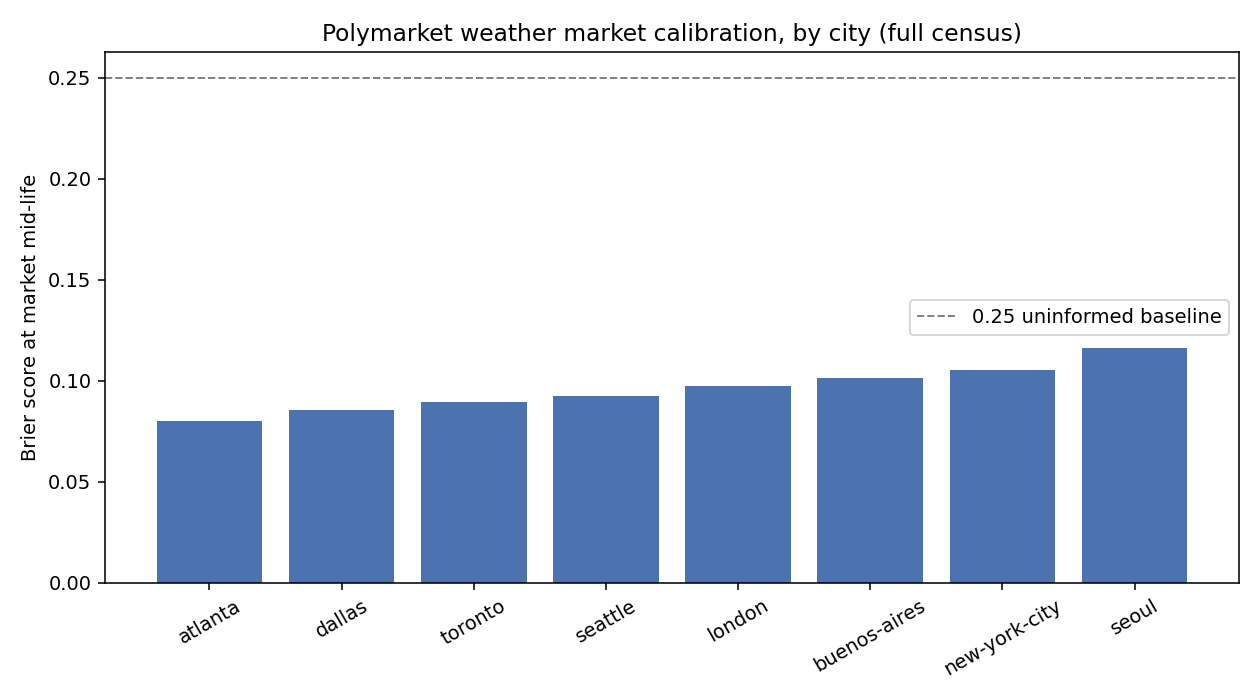

In [ ]:
import matplotlib.pyplot as plt

ranked = sorted(results.items(), key=lambda x: x[1]["brier"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([c for c, _ in ranked], [d["brier"] for _, d in ranked], color="#4C72B0")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="0.25 uninformed baseline")
ax.set_ylabel("Brier score at market mid-life")
ax.set_title("Polymarket weather market calibration, by city")
ax.tick_params(axis="x", rotation=30)
ax.legend()
fig.tight_layout()
plt.show()


**Atlanta calibrates best (0.080); Seoul worst (0.116).** London and New York —
the two cities with by far the deepest sample, over 2,300 resolved markets each — sit in the
middle of the pack, not at either extreme. Every city beats the 0.25 uninformed baseline by
a wide margin, but which city has the most data doesn't predict where it lands in the
ranking.

## Does sample size predict calibration?

London and New York have roughly ten times more resolved markets than any other city here,
and calibrate in the middle of the pack rather than at the top. That's worth checking
directly rather than leaving as an impression from one chart: is there any relationship
between how much data a city has and how well it calibrates?

In [ ]:
cities = list(results.keys())
log_n = [math.log(results[c]["n"]) for c in cities]
briers = [results[c]["brier"] for c in cities]

n = len(cities)
mean_x, mean_y = statistics.mean(log_n), statistics.mean(briers)
cov = sum((x-mean_x)*(y-mean_y) for x, y in zip(log_n, briers)) / n
sx, sy = statistics.pstdev(log_n), statistics.pstdev(briers)
r = cov / (sx*sy)
t = r * math.sqrt((n-2)/(1-r**2))
print(f"Pearson r = {r:.3f}  (n={n} cities, t={t:.3f}, df={n-2})")


Pearson r = 0.281  (n=8 cities, t=0.718, df=6)


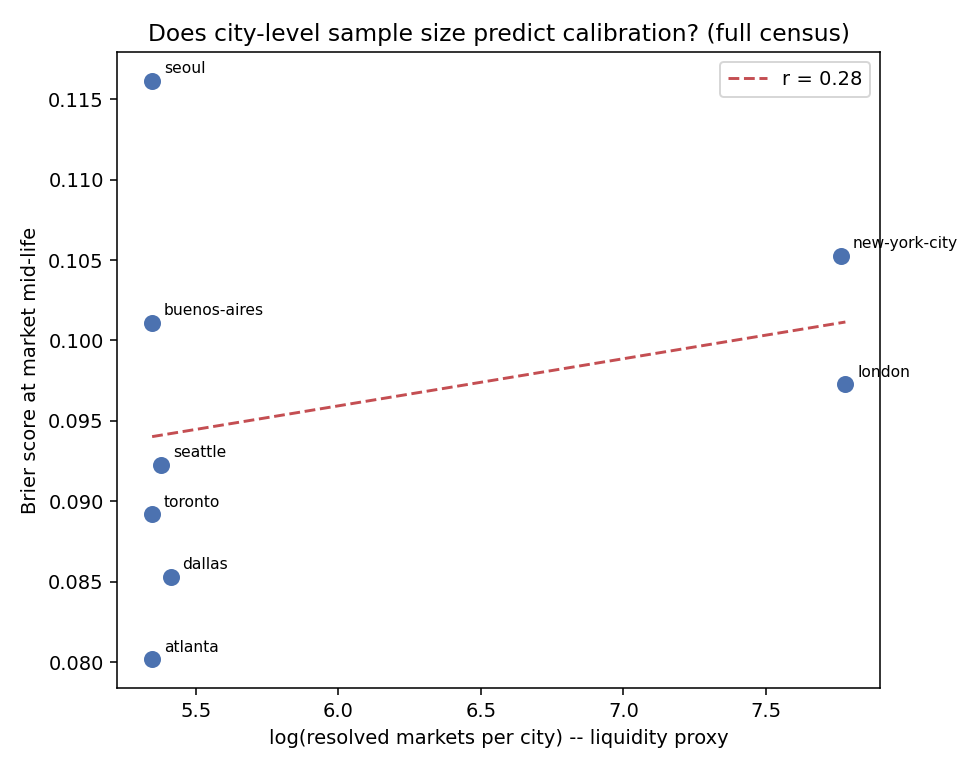

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(log_n, briers, s=60, color="#4C72B0", zorder=3)
for c, x, y in zip(cities, log_n, briers):
    ax.annotate(c, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8)
slope = cov / (sx**2)
intercept = mean_y - slope*mean_x
xs = [min(log_n), max(log_n)]
ax.plot(xs, [slope*x+intercept for x in xs], color="#C44E52", linestyle="--", linewidth=1.5, label=f"r = {r:.2f}")
ax.set_xlabel("log(resolved markets per city) -- liquidity proxy")
ax.set_ylabel("Brier score at market mid-life")
ax.set_title("Does city-level sample size predict calibration?")
ax.legend()
fig.tight_layout()
plt.show()


**No.** r = 0.28, t = 0.72 on 6 degrees of freedom — not significant, and in
the direction opposite a "more data, better calibration" story if anything. London and New
York calibrate worse than four of the six smaller cities despite an order of magnitude more
data each. Sample size doesn't predict calibration here, in either direction.

## Does calibration sharpen the same way across cities?

A single mid-life number can't show *when* a city's calibration improves — whether prices
start rough and sharpen near resolution, or stay noisy the whole way through. The
[category-level Brier study](/blog/brier-score-category-research) found that distinction
matters more than the midpoint score alone. Same check here, by city.

In [ ]:
for frac in CHECKPOINTS:
    pass  # multi-checkpoint computed in the same resolution pass as the mid-life result above

print(f"{'city':<18}" + "".join(f"{int(f*100):>8}%" for f in CHECKPOINTS))
for city in sorted(results, key=lambda c: results[c]["brier"]):
    row = f"{city:<18}"
    for frac in CHECKPOINTS:
        row += f"{multicheck_summary[city][frac]:8.4f}"
    print(row)


city                    10%      25%      50%      75%      90%
atlanta             0.1137  0.1049  0.0802  0.0559  0.0214
dallas              0.1159  0.1007  0.0853  0.0665  0.0298
toronto             0.1375  0.1224  0.0892  0.0676  0.0430
seattle             0.1254  0.1227  0.0923  0.0684  0.0318
london              0.1203  0.1100  0.0973  0.0756  0.0278
buenos-aires        0.1448  0.1172  0.1011  0.0728  0.0195
new-york-city       0.1283  0.1164  0.1053  0.0833  0.0316
seoul               0.1455  0.1341  0.1161  0.0647  0.0182


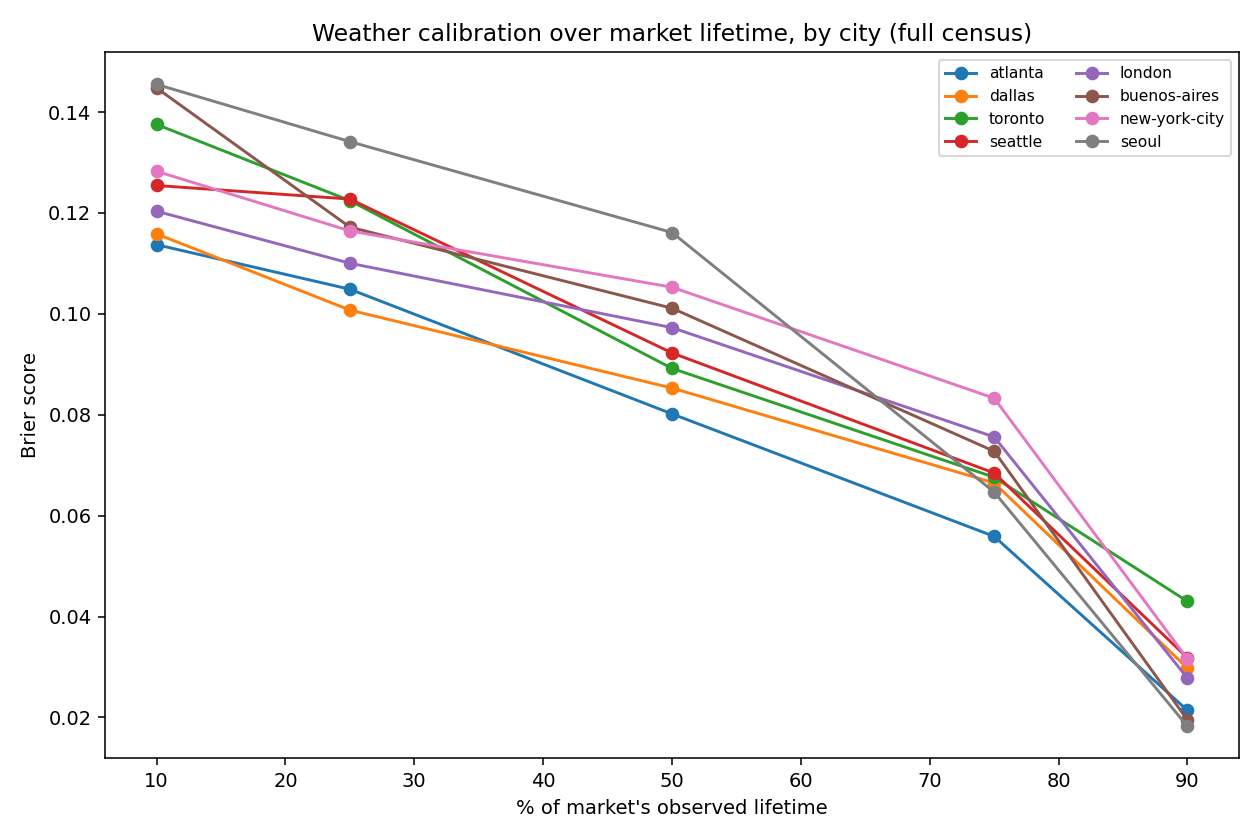

In [ ]:
import matplotlib.pyplot as plt

ranked = sorted(results.items(), key=lambda x: x[1]["brier"])
colors = plt.cm.tab10(range(len(ranked)))
fig, ax = plt.subplots(figsize=(9, 6))
for (city, _), color in zip(ranked, colors):
    ys = [multicheck_summary[city][f] for f in CHECKPOINTS]
    ax.plot([int(f*100) for f in CHECKPOINTS], ys, marker="o", label=city, color=color)
ax.set_xlabel("% of market's observed lifetime")
ax.set_ylabel("Brier score")
ax.set_title("Weather calibration over market lifetime, by city")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


**Every city sharpens toward resolution, and the ranking mostly holds across
checkpoints.** All eight cities improve substantially from the 10% to the 90% checkpoint —
weather markets behave like crypto and news in the category study, not like sports. Atlanta
and Dallas lead at every checkpoint from 10% through 75%; Seoul and Buenos Aires start
worst. By 90%, the gap narrows to a tight band (0.018-0.043) across all eight cities — late
in a weather market's life, which city it covers barely matters, consistent with the
forecast converging on a near-certain outcome for everyone close to the deadline, regardless
of city.

## Methodology limits

- **Resolution-outcome inference, not the on-chain record** — the 0.02/0.98 cutoff is a
  proxy, consistent with the rest of this research series.
- **Cities below 30 total files excluded**: Denver (15), Phoenix (14), Miami (14), Chicago
  (14), Los Angeles (14), Dubai (7).
- **119 files are a different kind of market, not a missed city.** A scan confirms they're
  hurricanes, earthquakes, monthly temperature records, and per-city "white Christmas"
  yes/no markets (Miami, Chicago, Boston, and others) — a different market structure (one
  binary outcome, not a temperature-bucket ladder) that this per-bucket methodology doesn't
  cover.

## Practical implications

- **Don't apply a liquidity-based confidence adjustment to Polymarket weather prices by
  city.** London and New York calibrate in the middle of the pack despite far more data
  than any other city — more history doesn't buy sharper pricing here.
- **Early-life weather prices vary more by city than late-life ones.** At the 10%
  checkpoint the gap between best (Atlanta, 0.114) and worst (Seoul, 0.146) is real; by 90%
  it's mostly gone. Which city you're pricing matters more early in a market's life than
  close to resolution.
- **Check a category's filename conventions against its full directory listing before
  computing per-entity sample sizes.** Mixed naming conventions are common in scraped
  market data, and a regex that only catches one of them will quietly undercount whatever
  entities happen to use the other — worth a `find | wc -l` sanity check against the
  regex's own match count on any new category parser in this research series.
- **For anyone extending this to more cities**: the six smaller cities here (210-224
  resolved markets each) already give the correlation test real statistical power at n=8
  cities. Adding Denver, Phoenix, Miami, Chicago, Los Angeles, or Dubai would need
  substantially more locally downloaded history first — each currently sits at 7-15 total
  files, well under the 30-file minimum.